In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
transform = transforms.ToTensor()
dataset = datasets.MNIST(root="./data",train=True, download=True, transform=transform)
loader = DataLoader(dataset, batch_size=128, shuffle=True)
#

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 492kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.43MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.71MB/s]


In [3]:
# 2. Define VAE model
class VAE(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.fc1 = nn.Linear(28*28, 128)
        self.fc_mu = nn.Linear(128, 2)      # 2D latent space
        self.fc_logvar = nn.Linear(128, 2)

        # Decoder
        self.fc2 = nn.Linear(2, 128)
        self.fc3 = nn.Linear(128, 28*28)

    def encode(self, x):
        x = x.view(-1, 28*28)
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

model = VAE()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [4]:
# 3. Loss function
def loss_fn(recon_x, x, mu, logvar):
    recon_loss = nn.functional.binary_cross_entropy(recon_x, x.view(-1, 28*28), reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss

In [5]:
# 4. Train model
epochs = 5
for epoch in range(epochs):
    total_loss = 0
    for x, _ in loader:
        optimizer.zero_grad()
        recon, mu, logvar = model(x)
        loss = loss_fn(recon, x, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.2f}")


Epoch 1, Loss: 12342435.62
Epoch 2, Loss: 10560586.25
Epoch 3, Loss: 10204960.86
Epoch 4, Loss: 10005622.32
Epoch 5, Loss: 9882987.32


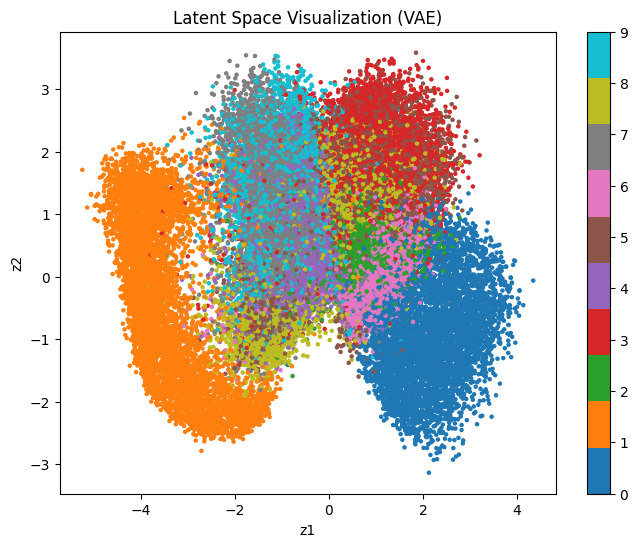

In [6]:

# 5. Visualize latent space
model.eval()
z_points = []
labels = []

with torch.no_grad():
    for x, y in loader:
        mu, _ = model.encode(x)
        z_points.append(mu)
        labels.append(y)

z = torch.cat(z_points).numpy()
labels = torch.cat(labels).numpy()

# Plot
plt.figure(figsize=(8,6))
plt.scatter(z[:,0], z[:,1], c=labels, cmap='tab10', s=5)
plt.colorbar()
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Latent Space Visualization (VAE)")
plt.show()

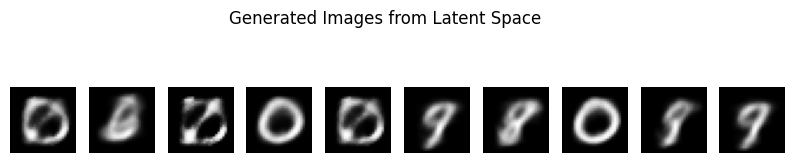

In [8]:
model.eval()

# Number of images to generate
num_samples = 10

# 1. Sample random points from the latent space (standard normal distribution)
# Since our latent space is 2D, we generate 2 * num_samples random values.
# We assume a standard normal distribution for sampling, as the KL divergence loss encourages this.
sampled_latent_vectors = torch.randn(num_samples, 2)

# 2. Pass these latent vectors through the decoder
with torch.no_grad():
    generated_images_flat = model.decode(sampled_latent_vectors)

# Reshape the output to 28x28 images
generated_images = generated_images_flat.view(num_samples, 1, 28, 28)

# 3. Visualize the generated images
plt.figure(figsize=(10, 2))
for i in range(num_samples):
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(generated_images[i].squeeze().numpy(), cmap='gray')
    plt.axis('off')
plt.suptitle('Generated Images from Latent Space', y=1.05)
plt.show()